In [1]:
from ucimlrepo import fetch_ucirepo, list_available_datasets

# Check available datasets
list_available_datasets()

# Example: Fetch Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

# Access features and targets
X = heart_disease.data.features
y = heart_disease.data.targets

print(X.head())
print(y.head())

print("\nDataset Information:")
print(heart_disease.metadata)

print("\nFeature Information:")
print(X.info())

print("\nMissing Values:")
print(X.isnull().sum())

print("\nTarget Distribution:")
print(y.value_counts())

# Convert target into binary classification
y_binary = (y["num"] > 0).astype(int)

# Handle missing values
X_clean = X.copy()
X_clean = X_clean.fillna(X_clean.median(numeric_only=True))

print("Missing values after cleaning:")
print(X_clean.isnull().sum())

print("\nBinary target distribution:")
print(y_binary.value_counts())


-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

In [2]:
# Convert target into binary classification
y_binary = (y["num"] > 0).astype(int)

# Handle missing values
X_clean = X.copy()
X_clean = X_clean.fillna(X_clean.median(numeric_only=True))

print("Missing values after cleaning:")
print(X_clean.isnull().sum())

print("\nBinary target distribution:")
print(y_binary.value_counts())

Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

Binary target distribution:
num
0    164
1    139
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (242, 13)
Testing features: (61, 13)
Training target: (242,)
Testing target: (61,)


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the model pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8688524590163934

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


Confusion Matrix:
[[27  6]
 [ 2 26]]


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.8852459016393442

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61


Confusion Matrix:
[[27  6]
 [ 1 27]]


In [7]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ]
})

display(results)

,Model,Accuracy,F1 Score
0,Logistic Regression,0.868852,0.866667
1,Random Forest,0.885246,0.885246


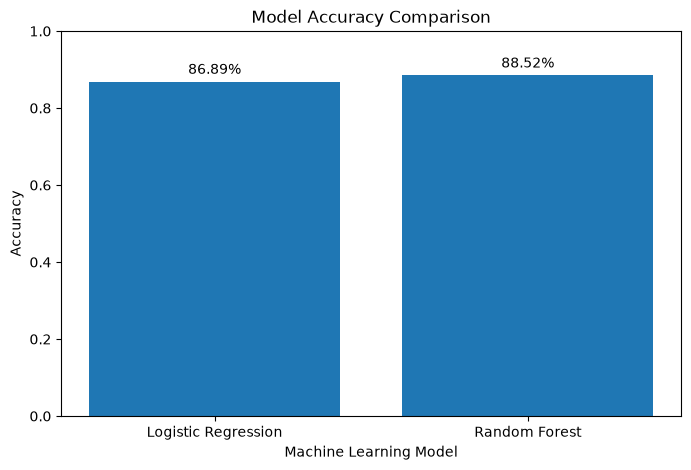

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(results["Accuracy"]):
    plt.text(i, value + 0.02, f"{value:.2%}", ha="center")

plt.show()


In [9]:
import pandas as pd

def predict_heart_risk(
    age,
    sex,
    cp,
    trestbps,
    chol,
    fbs,
    restecg,
    thalach,
    exang,
    oldpeak,
    slope,
    ca,
    thal
):
    # Create a DataFrame with the same feature order used during training
    unseen_data = pd.DataFrame([{
        "age": age,
        "sex": sex,
        "cp": cp,
        "trestbps": trestbps,
        "chol": chol,
        "fbs": fbs,
        "restecg": restecg,
        "thalach": thalach,
        "exang": exang,
        "oldpeak": oldpeak,
        "slope": slope,
        "ca": ca,
        "thal": thal
    }])

    # Predict class and probability
    prediction = rf_model.predict(unseen_data)[0]
    probability = rf_model.predict_proba(unseen_data)[0]

    if prediction == 1:
        result = "Higher heart disease risk detected"
    else:
        result = "Lower heart disease risk detected"

    print("Prediction:", result)
    print(f"Probability of lower risk: {probability[0]:.2%}")
    print(f"Probability of higher risk: {probability[1]:.2%}")

    return prediction

In [10]:
new_patient_prediction = predict_heart_risk(
    age=55,
    sex=1,
    cp=1,
    trestbps=140,
    chol=240,
    fbs=0,
    restecg=1,
    thalach=150,
    exang=0,
    oldpeak=1.0,
    slope=2,
    ca=0,
    thal=2
)

Prediction: Lower heart disease risk detected
Probability of lower risk: 71.50%
Probability of higher risk: 28.50%


In [11]:
import pandas as pd
from IPython.display import display

print("========== DATASET OVERVIEW ==========")
print("Original feature shape:", X.shape)
print("Target shape:", y.shape)

print("\n========== COLUMN NAMES ==========")
print(X.columns.tolist())

print("\n========== FIRST 10 ROWS ==========")
display(X.head(10))

print("\n========== LAST 10 ROWS ==========")
display(X.tail(10))

print("\n========== DATA TYPES AND MISSING VALUES ==========")
X.info()

print("\nMissing values:")
print(X.isnull().sum())

print("\n========== STATISTICAL SUMMARY ==========")
display(X.describe())

print("\n========== ORIGINAL TARGET DISTRIBUTION ==========")
print(y["num"].value_counts().sort_index())

print("\n========== CLEANED DATASET ==========")
dataset_checked = X_clean.copy()
dataset_checked["target"] = y_binary
display(dataset_checked.head(10))

print("\nCleaned dataset shape:", dataset_checked.shape)
print("\nCleaned dataset missing values:")
print(dataset_checked.isnull().sum())

========== DATASET OVERVIEW ==========
Original feature shape: (303, 13)
Target shape: (303, 1)

========== COLUMN NAMES ==========
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

========== FIRST 10 ROWS ==========


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0



========== LAST 10 ROWS ==========


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
293,63,1,4,140,187,0,2,144,1,4.0,1,2.0,7.0
294,63,0,4,124,197,0,0,136,1,0.0,2,0.0,3.0
295,41,1,2,120,157,0,0,182,0,0.0,1,0.0,3.0
296,59,1,4,164,176,1,2,90,0,1.0,2,2.0,6.0
297,57,0,4,140,241,0,0,123,1,0.2,2,0.0,7.0
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0



========== DATA TYPES AND MISSING VALUES ==========
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

===

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000



========== ORIGINAL TARGET DISTRIBUTION ==========
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

========== CLEANED DATASET ==========


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,1
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,1
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1



Cleaned dataset shape: (303, 14)

Cleaned dataset missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
